# FLIGHT DELAY DATA

```text
                    FLIGHT DELAY DATA
                           │
             ┌─────────────┴─────────────┐
             │                           │
             ▼                           ▼
      Regression Problem         Classification Problem
             │                           │
             ▼                           ▼
departure_delay_minutes       has_departure_delay_target
             │                           │
             ▼                           ▼
   "How many minutes?"             "Delayed or not?"

#### ---------------------------------------------------------------------------------------------------------------------------------------------

### The data conversion was done in jupyter notebook session below are the details 

# Flight Delay Dataset - Recommended Data Type Conversions

This document outlines the recommended data type conversions for the final merged flight delay dataset. The goals are to:

- Reduce memory usage
- Improve processing speed
- Use semantically correct data types
- Prepare the dataset for efficient machine learning

---

## Table of Contents

1. [Recommended Column Data Types](#recommended-column-data-types)
2. [Integer Data Types](#integer-data-types)
3. [Signed vs Unsigned Integers](#signed-vs-unsigned-integers)
4. [Why Int8 for Hour, Day and Month?](#why-int8-for-hour-day-and-month)
5. [Floating Point Data Types](#floating-point-data-types)
6. [Category Data Type](#category-data-type)
7. [Datetime Data Type](#datetime-data-type)
8. [Boolean Data Type](#boolean-data-type)
9. [Summary](#summary)

---

## Recommended Column Data Types

| Column | Current dtype | Recommended dtype | Reason |
|---|---|---|---|
| airline | object | category | Small set of repeated string codes |
| flight_number | object | Keep as object | Identifier, not a magnitude; should not be converted to numeric |
| origin_airport | object | category | Repeated airport codes |
| destination_airport | object | category | Repeated airport codes |
| scheduled_departure | datetime64[ns] | Already correct | No change needed |
| actual_departure | object | datetime64[ns] | Timestamp currently stored as string |
| scheduled_arrival | object | datetime64[ns] | Mixed millisecond formatting caused object dtype |
| actual_arrival | object | datetime64[ns] | Timestamp currently stored as string |
| flight_status | object | category | Small set of repeated values |
| cancellation_reason | object | category | Small set of repeated values with many nulls |
| flight_type | object | category | Small set of repeated values |
| country | object | category | Only two values (US, Brazil) |
| cancellation_reason_available | bool | Already correct | No change needed |
| departure_delay_minutes | float64 | float32 | Continuous numeric value; float64 precision is unnecessary |
| has_departure_delay_target | bool | Already correct | No change needed |
| arrival_delay_minutes | float64 | float32 | Continuous numeric value |
| scheduled_flight_duration_minutes | float64 | float32 | Continuous numeric value |
| hour_of_day | float64 | Int8 (nullable) | Integer values between 0 and 23 |
| day_of_week | float64 | Int8 (nullable) | Integer values between 0 and 6 |
| month | float64 | Int8 (nullable) | Integer values between 1 and 12 |
| is_weekend | bool | Already correct | No change needed |
| is_redeye | bool | Already correct | No change needed |
| route | object | category | Repeated origin-destination pairs |
| weather_hour | datetime64[ns] | Already correct | No change needed |
| temperature_2m_c | float64 | float32 | Continuous numeric value |
| windspeed_10m_ms | float64 | float32 | Continuous numeric value |
| windgusts_10m_ms | float64 | float32 | Continuous numeric value |
| visibility_m | float64 | float32 | Continuous numeric value |
| precipitation_mm | float64 | float32 | Continuous numeric value |
| snowfall_cm | float64 | float32 | Continuous numeric value |
| cloudcover_low_pct | float64 | float32 | Continuous numeric value |
| weathercode | float64 | category (via Int64 first) | WMO weather code is a categorical label, not a continuous value |
| weather_station_id | object | category | Repeated weather station identifiers |
| is_substitute_station | float64 | boolean (nullable) | Currently stored as 0.0/1.0 but represents True/False |
| station_distance_km | object | float32 (after inspection) | Appears numeric but must be checked for non-numeric values first |

---

## Integer Data Types

Integer types store **whole numbers** (no decimal point).

| Type | Size | Range |
|---|---:|---|
| Int8 | 1 byte | -128 to 127 |
| UInt8 | 1 byte | 0 to 255 |
| Int16 | 2 bytes | -32,768 to 32,767 |
| UInt16 | 2 bytes | 0 to 65,535 |
| Int32 | 4 bytes | -2,147,483,648 to 2,147,483,647 |
| UInt32 | 4 bytes | 0 to 4,294,967,295 |
| Int64 | 8 bytes | -9,223,372,036,854,775,808 to 9,223,372,036,854,775,807 |
| UInt64 | 8 bytes | 0 to 18,446,744,073,709,551,615 |

---

## Signed vs Unsigned Integers

### Signed Integers (`Int`)

Signed integers can store both negative and positive numbers.

Example:

```text
-5
-1
0
12
100
```

Used when negative values are possible (e.g., delay can be negative for early departures).

### Unsigned Integers (`UInt`)

Unsigned integers can only store non-negative values.

Example:

```text
0
1
2
255
```

Used when values are guaranteed to never be negative (e.g., image pixel values).

---

## Why Int8 for Hour, Day and Month?

These columns only contain small integer values.

| Column | Possible Values |
|---|---|
| hour_of_day | 0 – 23 |
| day_of_week | 0 – 6 |
| month | 1 – 12 |

Since all values fall within **-128 to 127**, `Int8` is the smallest suitable integer type.

Benefits:

- Uses only **1 byte per value**
- Supports nullable values (`NA`)
- Reduces memory usage significantly compared to `float64`

---



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
df = pd.read_parquet(
    "/kaggle/input/datasets/tjaycuz/flight-delay-dataset/flight_delay_dataset_2022_2026_US_Brazil_with_weather.parquet"
)

In [3]:
df.head()

,airline,flight_number,origin_airport,destination_airport,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,flight_status,cancellation_reason,flight_type,country,cancellation_reason_available,departure_delay_minutes,has_departure_delay_target,arrival_delay_minutes,scheduled_flight_duration_minutes,hour_of_day,day_of_week,month,is_weekend,is_redeye,route,weather_hour,temperature_2m_c,windspeed_10m_ms,windgusts_10m_ms,visibility_m,precipitation_mm,snowfall_cm,cloudcover_low_pct,weathercode,weather_station_id,is_substitute_station,station_distance_km
0,9E,4732,ABE,DTW,2022-04-01 05:55:00,2022-04-01 06:09:00,2022-04-01 07:54:00,2022-04-01 07:45:00,Completed,NaN,Domestic,US,False,14.00,True,-9.00,119.00,5,4,4,False,True,ABE-DTW,2022-04-01 05:00:00,12.78,1.04,NaN,"3,701.40",0.48,NaN,30.00,61.00,72517014737,False,0.00
1,OH,5600,ABE,CLT,2022-04-01 06:05:00,2022-04-01 06:00:00,2022-04-01 08:20:00,2022-04-01 07:44:00,Completed,NaN,Domestic,US,False,-5.00,True,-36.00,135.00,6,4,4,False,True,ABE-CLT,2022-04-01 06:00:00,12.50,3.10,NaN,"5,628.00",18.50,NaN,87.50,10.00,72517014737,False,0.00
2,G4,312,ABE,PGD,2022-04-01 07:00:00,2022-04-01 06:57:00,2022-04-01 09:40:00,2022-04-01 09:55:00,Completed,NaN,Domestic,US,False,-3.00,True,15.00,160.00,7,4,4,False,False,ABE-PGD,2022-04-01 07:00:00,11.10,3.10,NaN,"16,093.00",0.00,NaN,87.50,NaN,72517014737,False,0.00
3,G4,403,ABE,PIE,2022-04-01 08:00:00,2022-04-01 12:50:00,2022-04-01 10:36:00,2022-04-01 15:43:00,Completed,NaN,Domestic,US,False,290.00,True,307.00,156.00,8,4,4,False,False,ABE-PIE,2022-04-01 08:00:00,10.60,4.60,NaN,"16,093.00",0.00,NaN,25.00,NaN,72517014737,False,0.00
4,G4,401,ABE,SFB,2022-04-01 12:53:00,2022-04-01 13:26:00,2022-04-01 15:18:00,2022-04-01 15:59:00,Completed,NaN,Domestic,US,False,33.00,True,41.00,145.00,12,4,4,False,False,ABE-SFB,2022-04-01 12:00:00,8.60,3.60,NaN,"16,046.50",0.50,NaN,87.50,NaN,72517014737,False,0.00


In [4]:
df.tail()

,airline,flight_number,origin_airport,destination_airport,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,flight_status,cancellation_reason,flight_type,country,cancellation_reason_available,departure_delay_minutes,has_departure_delay_target,arrival_delay_minutes,scheduled_flight_duration_minutes,hour_of_day,day_of_week,month,is_weekend,is_redeye,route,weather_hour,temperature_2m_c,windspeed_10m_ms,windgusts_10m_ms,visibility_m,precipitation_mm,snowfall_cm,cloudcover_low_pct,weathercode,weather_station_id,is_substitute_station,station_distance_km
34809031,TAM,3373,SBGO,SBGR,2025-09-25 09:50:00,2025-09-25 10:10:00,2025-09-25 11:25:00,2025-09-25 11:49:00,Completed,NaN,Domestic Mixed,Brazil,False,20.00,True,24.00,95.00,9,3,9,False,False,SBGO-SBGR,2025-09-25 09:00:00,19.80,3.00,5.20,"24,140.00",0.00,0.00,0.00,0.00,0,False,NaN
34809032,TAM,3373,SBGO,SBGR,2025-09-26 09:50:00,2025-09-26 09:49:00,2025-09-26 11:25:00,2025-09-26 11:23:00,Completed,NaN,Domestic Mixed,Brazil,False,-1.00,True,-2.00,95.00,9,4,9,False,False,SBGO-SBGR,2025-09-26 09:00:00,19.80,3.66,6.30,"24,140.00",0.00,0.00,0.00,0.00,0,False,NaN
34809033,TAM,3373,SBGO,SBGR,2025-09-27 09:50:00,2025-09-27 09:50:00,2025-09-27 11:25:00,2025-09-27 11:23:00,Completed,NaN,Domestic Mixed,Brazil,False,0.00,True,-2.00,95.00,9,5,9,True,False,SBGO-SBGR,2025-09-27 09:00:00,19.10,4.44,6.30,"24,140.00",0.00,0.00,0.00,0.00,0,False,NaN
34809034,TAM,3373,SBGO,SBGR,2025-09-28 09:50:00,2025-09-28 10:02:00,2025-09-28 11:25:00,2025-09-28 11:34:00,Completed,NaN,Domestic Mixed,Brazil,False,12.00,True,9.00,95.00,9,6,9,True,False,SBGO-SBGR,2025-09-28 09:00:00,20.60,3.02,4.00,"24,140.00",0.00,0.00,0.00,0.00,0,False,NaN
34809035,TAM,3373,SBGO,SBGR,2025-09-29 09:50:00,2025-09-29 09:48:00,2025-09-29 11:25:00,2025-09-29 11:23:00,Completed,NaN,Domestic Mixed,Brazil,False,-2.00,True,-2.00,95.00,9,0,9,False,False,SBGO-SBGR,2025-09-29 09:00:00,22.00,3.71,2.70,"24,140.00",0.00,0.00,0.00,0.00,0,False,NaN


In [5]:
df.describe().style.set_sticky(axis="index")

,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,departure_delay_minutes,arrival_delay_minutes,scheduled_flight_duration_minutes,hour_of_day,day_of_week,month,weather_hour,temperature_2m_c,windspeed_10m_ms,windgusts_10m_ms,visibility_m,precipitation_mm,snowfall_cm,cloudcover_low_pct,weathercode,station_distance_km
count,34672385,34124003,34672383,34098562,33987352.000000,33961911.000000,34672383.000000,34672385.000000,34672385.000000,34672385.000000,34672385,34456799.000000,34446700.000000,10032965.000000,34391382.000000,30685453.000000,6747911.000000,32814896.000000,8860652.000000,34141634.000000
mean,2024-03-27 03:47:34.672398080,2024-03-28 16:09:20.261090304,2024-03-27 06:15:22.691765760,2024-03-28 18:19:39.936499968,4.655384,-0.044953,147.817413,12.994218,2.984884,6.241134,2024-03-27 03:20:38.615297024,16.766190,3.479998,7.913473,17126.632812,0.169178,0.597249,39.320190,19.321859,8696170496.000000
min,2022-01-01 00:01:00,2021-12-31 23:50:00,2022-01-01 01:20:00,2022-01-01 00:49:00,-524906.000000,-524907.000000,-272.000000,0.000000,0.000000,1.000000,2022-01-01 00:00:00,-47.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-02-24 05:35:00,2023-02-27 07:56:00,2023-02-24 07:30:00,2023-02-27 10:25:00,-6.000000,-15.000000,90.000000,9.000000,1.000000,3.000000,2023-02-24 05:00:00,10.000000,2.000000,4.100000,16046.500000,0.000000,0.000000,16.000000,0.000000,0.000000
50%,2024-04-04 11:15:00,2024-04-06 06:38:00,2024-04-04 13:43:00,2024-04-06 08:35:00,-2.000000,-6.000000,127.000000,13.000000,3.000000,6.000000,2024-04-04 11:00:00,18.000000,3.100000,8.200000,16093.000000,0.000000,0.000000,25.000000,3.000000,0.000000
75%,2025-05-03 07:20:00,2025-05-03 17:40:00,2025-05-03 09:48:00,2025-05-03 19:12:00,9.000000,9.000000,177.000000,17.000000,5.000000,9.000000,2025-05-03 07:00:00,24.400000,4.600000,10.800000,16093.000000,0.000000,0.000000,56.000000,51.000000,0.000000
max,2026-06-01 19:50:00.100000,2026-06-01 23:06:00,2026-06-02 08:50:00.100000,2026-06-02 07:32:00,1052705.000000,1052686.000000,1510.000000,23.000000,6.000000,12.000000,2026-06-01 19:00:00,51.700001,50.400002,58.200001,160000.000000,999.599976,150.000000,100.000000,97.000000,94866096128.000000
std,nan,nan,nan,nan,223.742233,224.687469,81.635284,5.024609,2.003941,3.429544,nan,9.678755,2.131303,4.317628,11000.333008,1.414561,4.109074,33.579842,27.235355,25568778240.000000


In [6]:
df.shape

(34809036, 35)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34809036 entries, 0 to 34809035
Data columns (total 35 columns):
 #   Column                             Dtype         
---  ------                             -----         
 0   airline                            category      
 1   flight_number                      object        
 2   origin_airport                     category      
 3   destination_airport                category      
 4   scheduled_departure                datetime64[ns]
 5   actual_departure                   datetime64[ns]
 6   scheduled_arrival                  datetime64[ns]
 7   actual_arrival                     datetime64[ns]
 8   flight_status                      category      
 9   cancellation_reason                category      
 10  flight_type                        category      
 11  country                            category      
 12  cancellation_reason_available      bool          
 13  departure_delay_minutes            float32       
 14  

In [8]:
df.isnull().sum()

airline                                     0
flight_number                               1
origin_airport                              0
destination_airport                         0
scheduled_departure                    136651
actual_departure                       685033
scheduled_arrival                      136653
actual_arrival                         710474
flight_status                               0
cancellation_reason                  34274553
flight_type                               466
country                                     0
cancellation_reason_available               0
departure_delay_minutes                821684
has_departure_delay_target                  0
arrival_delay_minutes                  847125
scheduled_flight_duration_minutes      136653
hour_of_day                            136651
day_of_week                            136651
month                                  136651
is_weekend                                  0
is_redeye                         

In [9]:
df.duplicated().sum()

np.int64(21)

In [10]:
df.columns

Index(['airline', 'flight_number', 'origin_airport', 'destination_airport',
       'scheduled_departure', 'actual_departure', 'scheduled_arrival',
       'actual_arrival', 'flight_status', 'cancellation_reason', 'flight_type',
       'country', 'cancellation_reason_available', 'departure_delay_minutes',
       'has_departure_delay_target', 'arrival_delay_minutes',
       'scheduled_flight_duration_minutes', 'hour_of_day', 'day_of_week',
       'month', 'is_weekend', 'is_redeye', 'route', 'weather_hour',
       'temperature_2m_c', 'windspeed_10m_ms', 'windgusts_10m_ms',
       'visibility_m', 'precipitation_mm', 'snowfall_cm', 'cloudcover_low_pct',
       'weathercode', 'weather_station_id', 'is_substitute_station',
       'station_distance_km'],
      dtype='object')

In [11]:
# Unique values for categorical/object columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    unique_vals = df[col].dropna().unique()
    
    print(f"\n{'='*60}")
    print(f"{col}")
    print(f"Unique values: {len(unique_vals):,}")
    
    # Show all values if small; otherwise show only the first 20
    if len(unique_vals) <= 20:
        print(unique_vals)
    else:
        print("First 20 values:")
        print(unique_vals[:20])


airline
Unique values: 186
First 20 values:
['9E', 'OH', 'G4', 'MQ', 'AS', ..., 'NK', 'HA', 'GLO', 'QTR', 'ACN']
Length: 20
Categories (186, object): ['1DE', '1ED', '9E', 'AA', ..., 'WIN', 'WN', 'YV', 'YX']

flight_number
Unique values: 14,887
First 20 values:
['4732' '5600' '312' '403' '401' '331' '4991' '5502' '608' '334' '387'
 '344' '4814' '353' '336' '5052' '5111' '3869' '5375' '4041']

origin_airport
Unique values: 981
First 20 values:
['ABE', 'ADQ', 'ALB', 'ABY', 'AMA', ..., 'AUS', 'ATL', 'ABQ', 'AGS', 'AZA']
Length: 20
Categories (981, object): ['ABE', 'ABI', 'ABQ', 'ABR', ..., 'ZHCC', 'ZHHH', 'ZSPD', 'ZUUU']

destination_airport
Unique values: 989
First 20 values:
['DTW', 'CLT', 'PGD', 'PIE', 'SFB', ..., 'MDW', 'DCA', 'MCO', 'MIA', 'LGA']
Length: 20
Categories (989, object): ['ABE', 'ABI', 'ABQ', 'ABR', ..., 'ZGSZ', 'ZSPD', 'ZUUU', 'ZWTP']

flight_status
Unique values: 4
['Completed', 'Cancelled', 'Diverted', 'Unknown']
Categories (4, object): ['Cancelled', 'Completed', 'Dive

### Distribution Analysis

## ****We're deliberately sampling at most 100,000 rows

In [12]:
# Numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numeric_cols))

Numerical columns:
['departure_delay_minutes', 'arrival_delay_minutes', 'scheduled_flight_duration_minutes', 'hour_of_day', 'day_of_week', 'month', 'temperature_2m_c', 'windspeed_10m_ms', 'windgusts_10m_ms', 'visibility_m', 'precipitation_mm', 'snowfall_cm', 'cloudcover_low_pct', 'weathercode', 'station_distance_km']


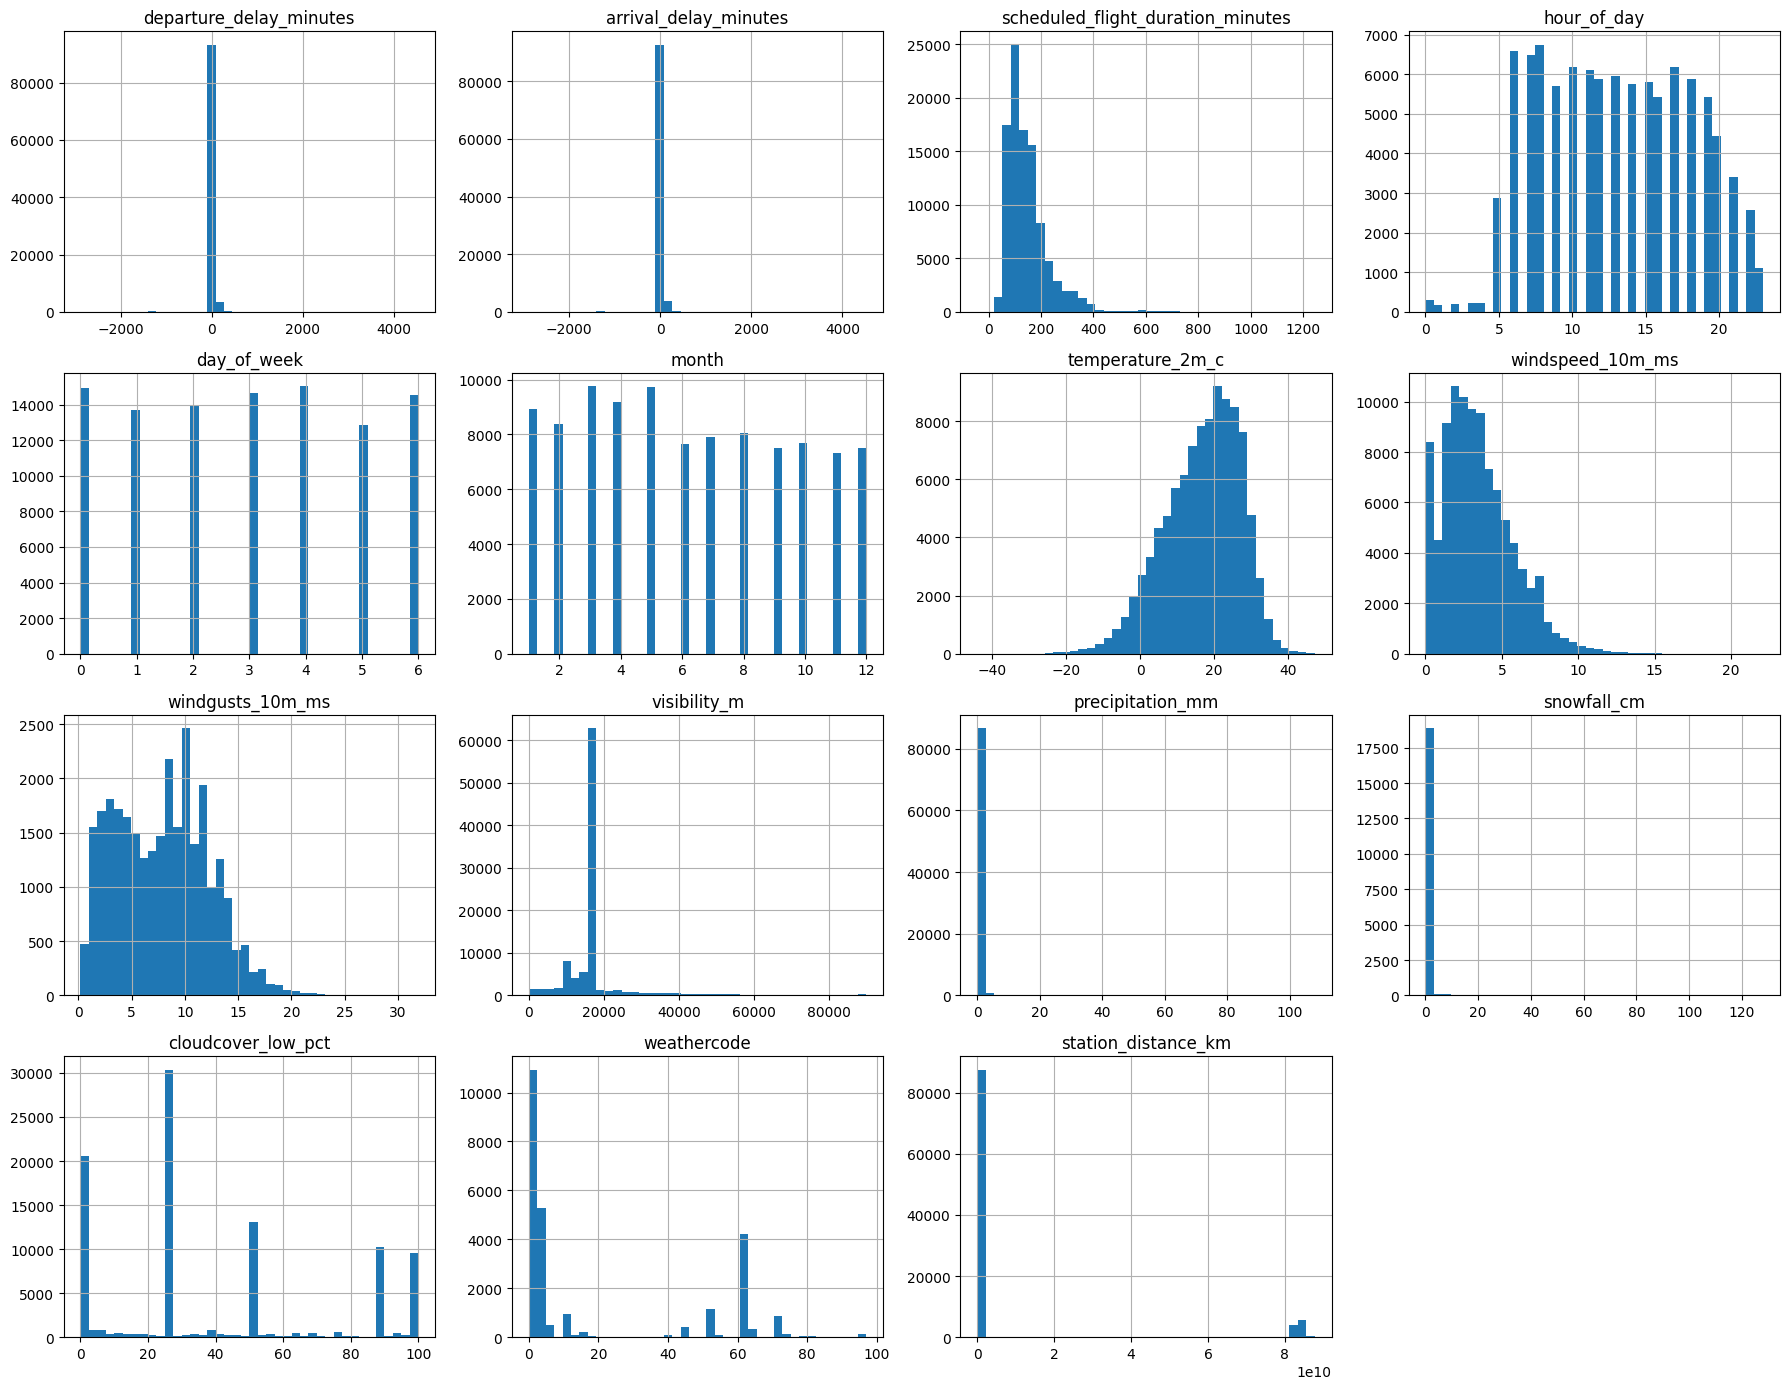

In [13]:
# Distribution analysis
df[numeric_cols].sample(
    min(100_000, len(df)),
    random_state=42
).hist(
    figsize=(18, 14),
    bins=40
)

plt.tight_layout()
plt.show()

### Target Variable Analysis

In [14]:
target = "departure_delay_minutes"

df[target].describe()

count   33,987,352.00
mean             4.66
std            223.74
min       -524,906.00
25%             -6.00
50%             -2.00
75%              9.00
max      1,052,705.00
Name: departure_delay_minutes, dtype: float64

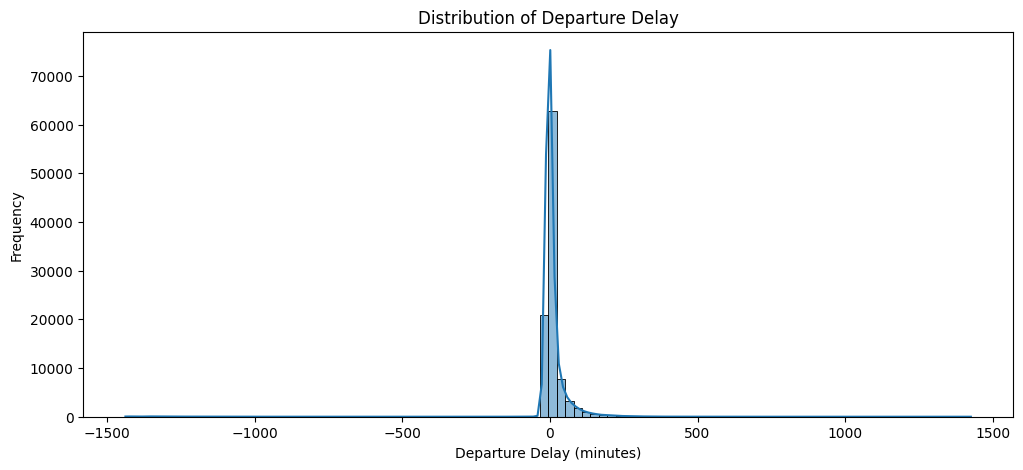

In [15]:
plt.figure(figsize=(12, 5))

sns.histplot(
    df[target].dropna().sample(
        min(100_000, df[target].notna().sum()),
        random_state=42
    ),
    bins=100,
    kde=True
)

plt.title("Distribution of Departure Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Frequency")

plt.show()

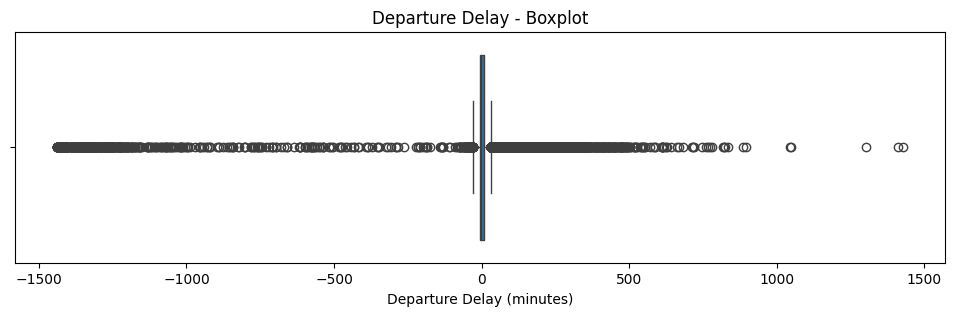

In [16]:
plt.figure(figsize=(12, 3))

sns.boxplot(
    x=df[target].dropna().sample(
        min(100_000, df[target].notna().sum()),
        random_state=42
    )
)

plt.title("Departure Delay - Boxplot")
plt.xlabel("Departure Delay (minutes)")

plt.show()

### Skewness

Top skewed features:


,Skewness
departure_delay_minutes,"2,662.70"
arrival_delay_minutes,"2,621.80"
precipitation_mm,65.01
snowfall_cm,10.46
visibility_m,3.60
station_distance_km,2.59


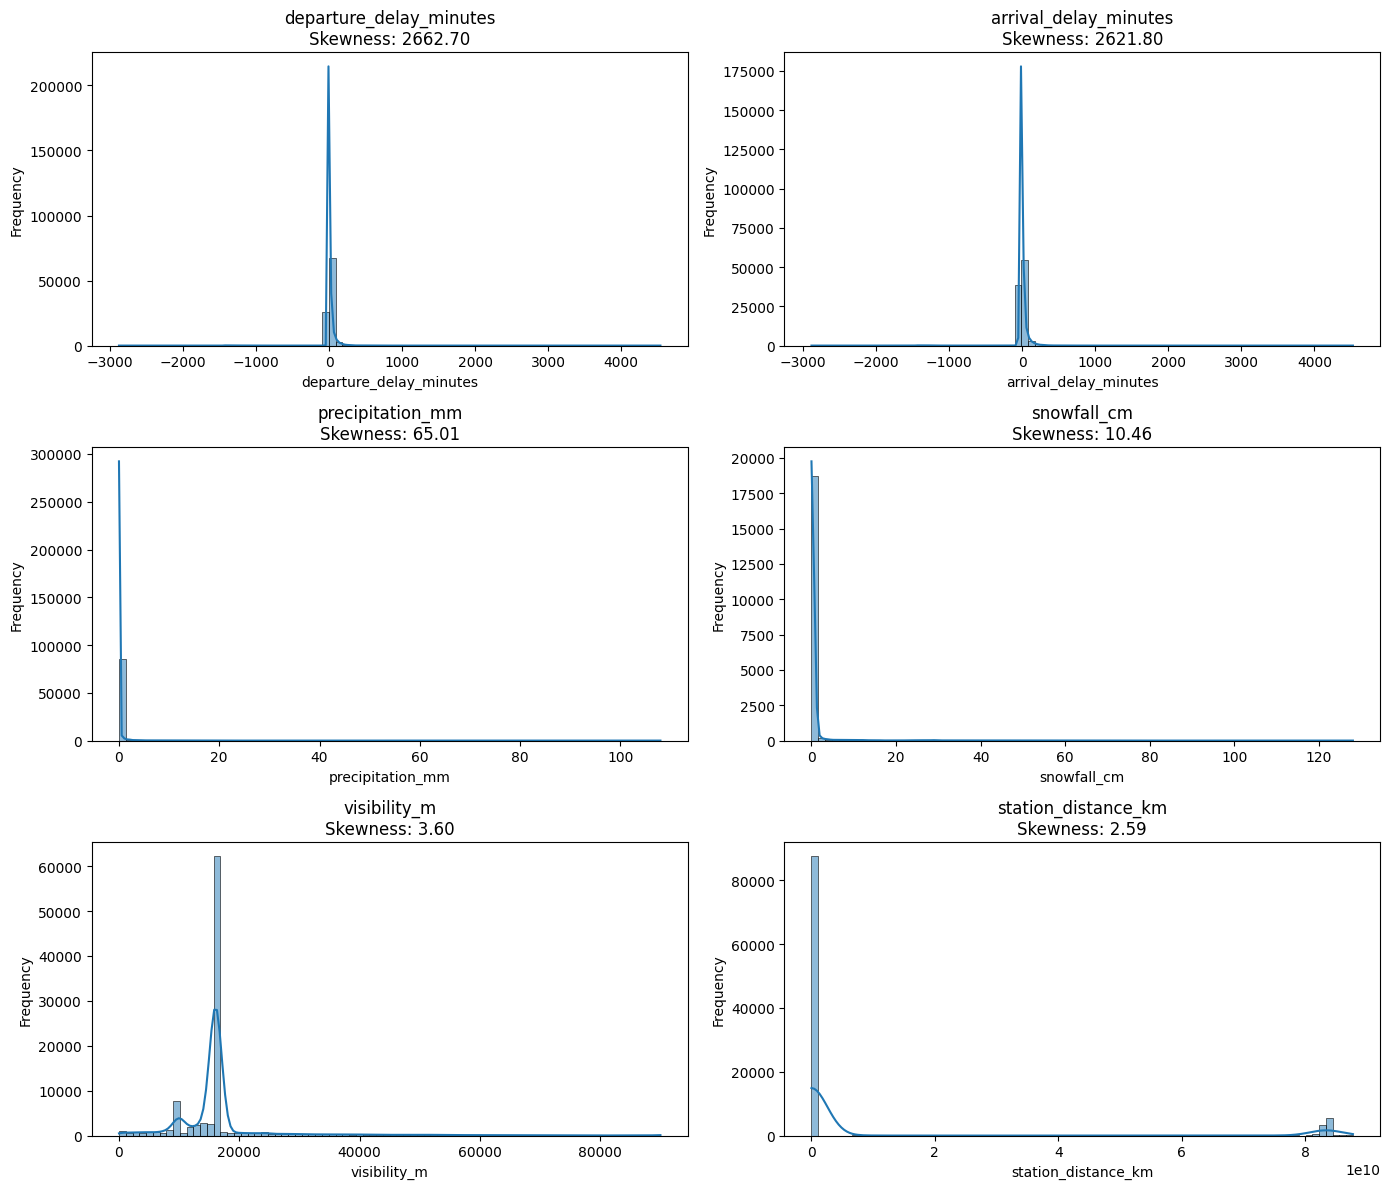

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate skewness on full data (safe, pandas handles this efficiently)
skewness = df[numeric_cols].skew().sort_values(ascending=False)

# Select top 6 most skewed features
top_skewed = skewness.abs().sort_values(ascending=False).head(6).index

print("Top skewed features:")
display(skewness[top_skewed].to_frame("Skewness"))

# Sample data only for plotting
plot_sample = df[top_skewed].sample(
    n=min(100000, len(df)),
    random_state=42
)

# Create plots
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12)
)

axes = axes.flatten()

for i, col in enumerate(top_skewed):

    sns.histplot(
        plot_sample[col].dropna(),
        kde=True,
        bins=80,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{col}\nSkewness: {skewness[col]:.2f}"
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Correlation

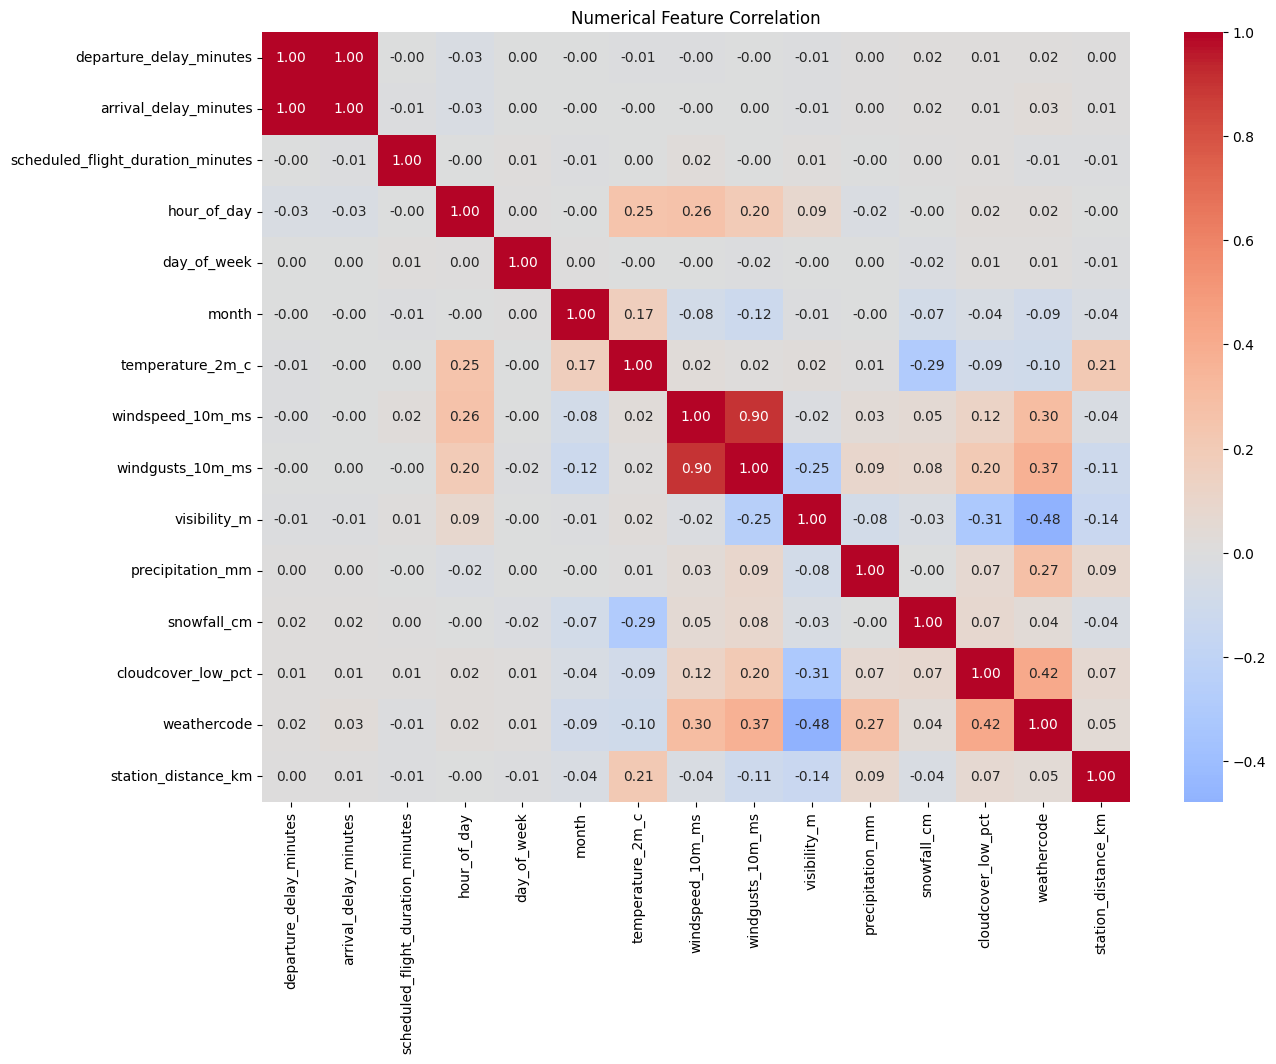

In [18]:
correlation = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation")

plt.show()

### Outlier Detection

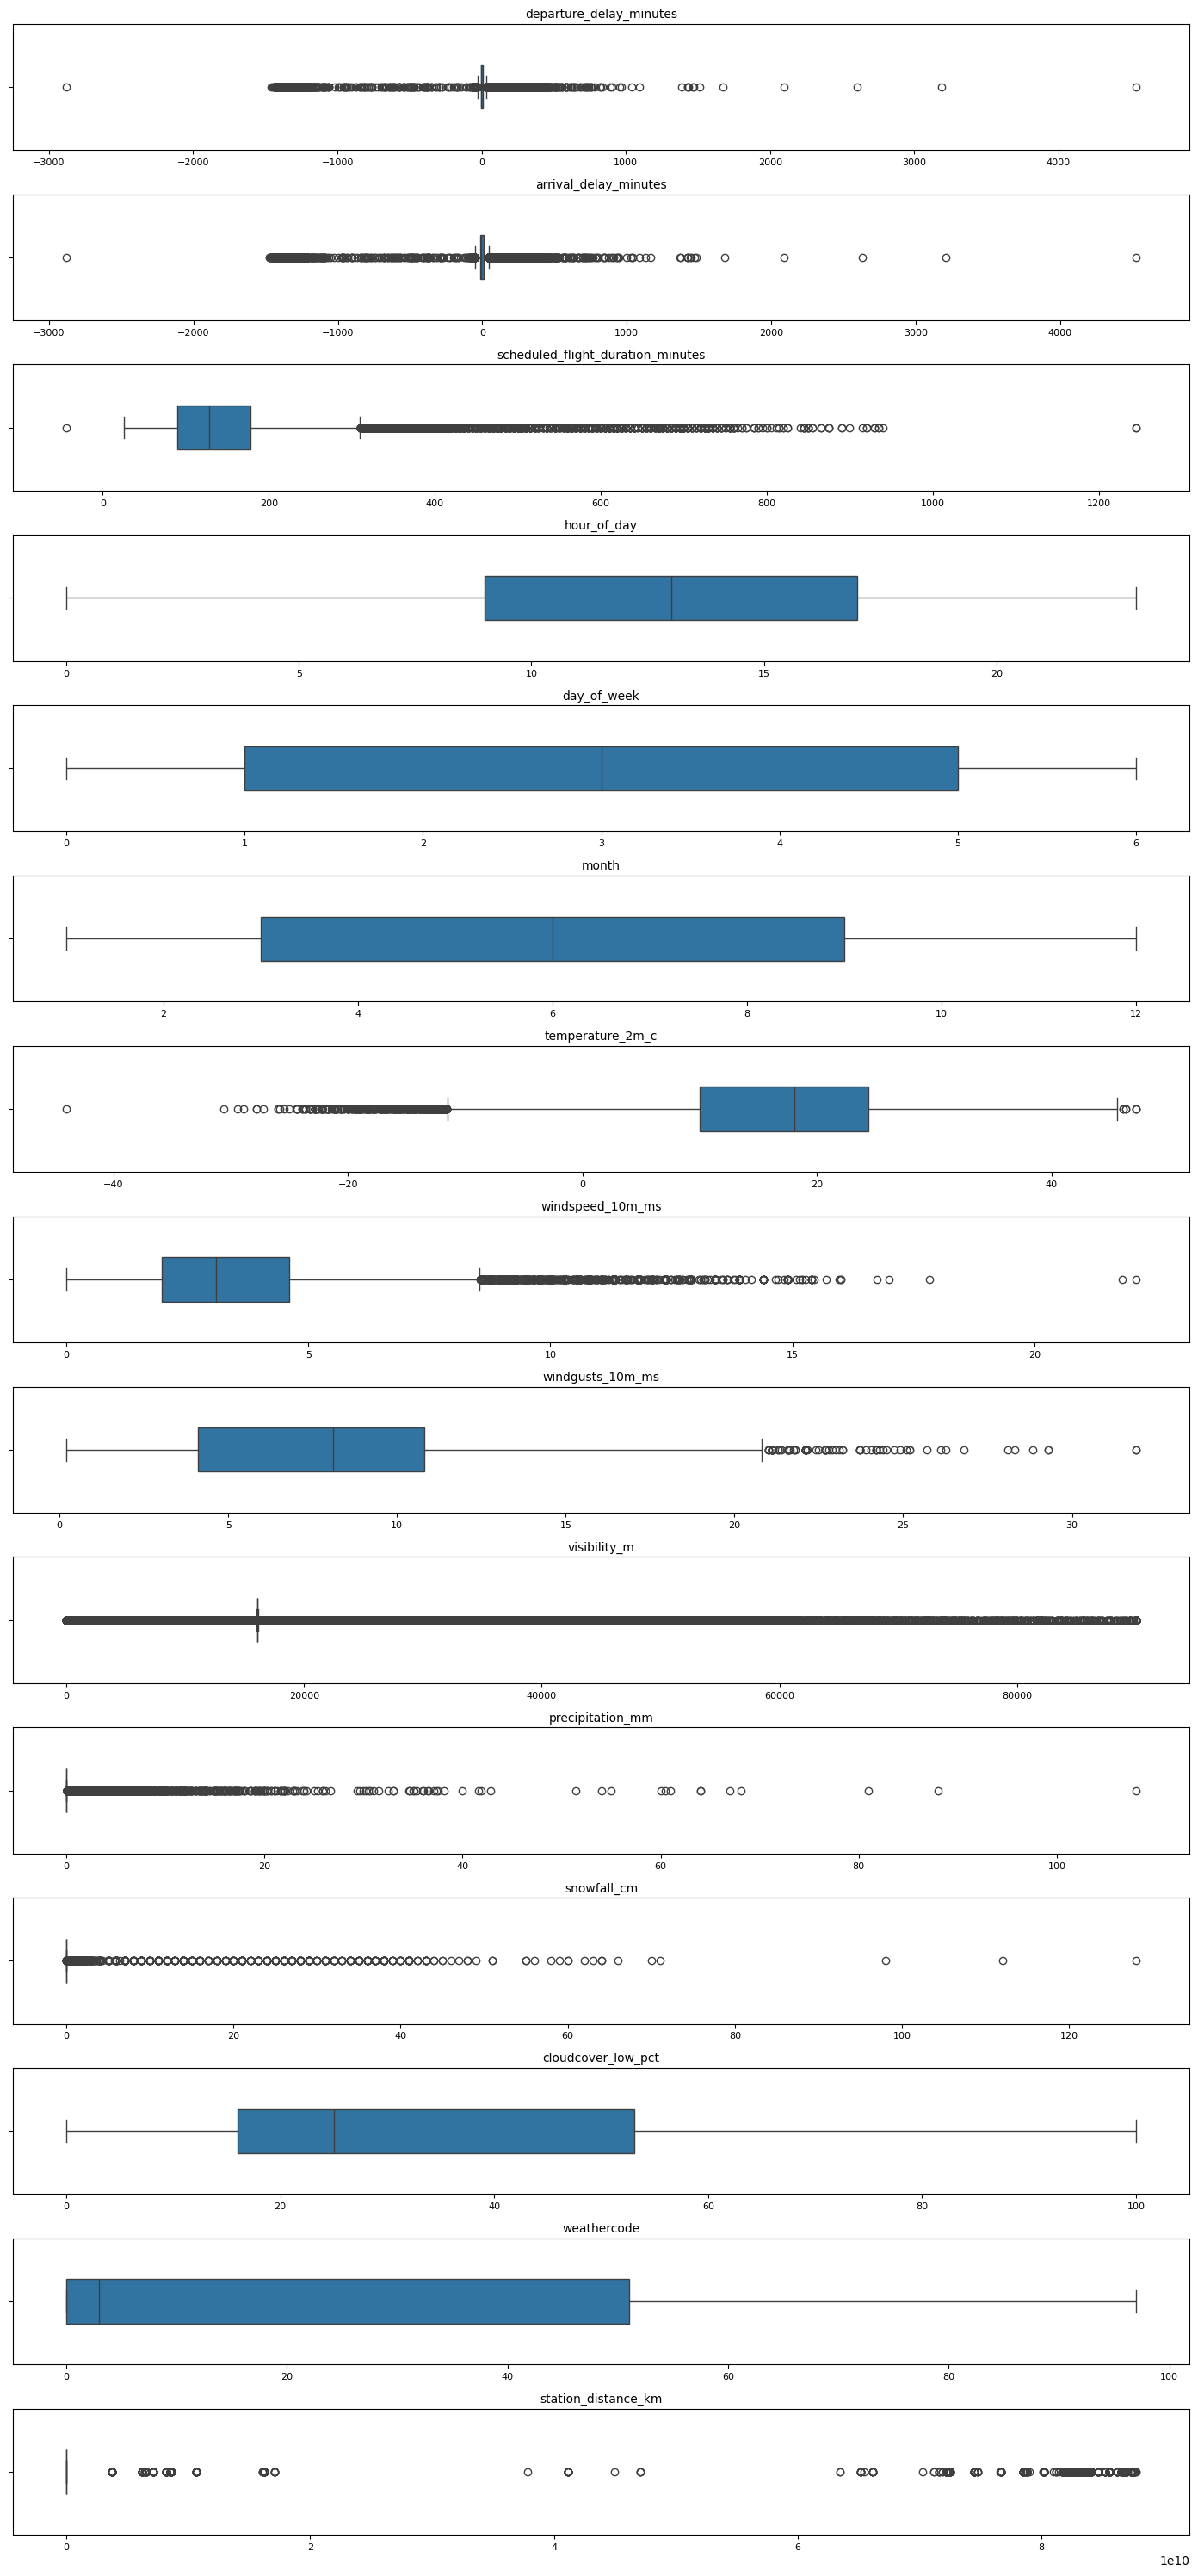

In [19]:
# Compact boxplots for all numerical columns

numeric_cols = df.select_dtypes(include=np.number).columns

# Sample for visualization
plot_df = df[numeric_cols].sample(
    min(100000, len(df)),
    random_state=42
)

# Create compact layout
n_rows = len(numeric_cols)

fig, axes = plt.subplots(
    n_rows,
    1,
    figsize=(14, 2 * n_rows),   # smaller height per plot
    sharex=False
)

if n_rows == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    
    sns.boxplot(
        x=plot_df[col],
        ax=axes[i],
        width=0.35
    )
    
    axes[i].set_title(
        f"{col}",
        fontsize=10,
        pad=5
    )
    
    axes[i].set_xlabel("")
    
    # Reduce empty space
    axes[i].tick_params(axis='both', labelsize=8)

plt.tight_layout(pad=1)

plt.show()

### Categorical analysis below

In [20]:
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['airline', 'flight_number', 'origin_airport', 'destination_airport', 'flight_status', 'cancellation_reason', 'flight_type', 'country', 'route', 'weather_station_id']


In [21]:
cat_analysis = pd.DataFrame({
    "Unique_Count": df[categorical_cols].nunique(),
    "Missing_Count": df[categorical_cols].isna().sum(),
    "Most_Common": [
        df[col].mode()[0] if df[col].notna().any() else None
        for col in categorical_cols
    ],
    "Most_Common_Frequency": [
        df[col].value_counts(normalize=True).iloc[0]
        if df[col].notna().any() else 0
        for col in categorical_cols
    ]
})

cat_analysis["Dominance_%"] = (
    cat_analysis["Most_Common_Frequency"] * 100
)

cat_analysis.sort_values(
    "Unique_Count",
    ascending=False
)

,Unique_Count,Missing_Count,Most_Common,Most_Common_Frequency,Dominance_%
flight_number,14887,1,777,0.00,0.04
route,14113,0,SBRJ-SBSP,0.00,0.23
destination_airport,989,0,ATL,0.04,4.13
origin_airport,981,0,ATL,0.04,4.13
weather_station_id,382,31783,0,0.12,12.28
airline,186,0,WN,0.18,17.59
flight_type,6,466,Domestic,0.88,87.73
flight_status,4,0,Completed,0.98,97.76
cancellation_reason,4,34274553,B,0.57,57.38
country,2,0,US,0.88,87.73


Low-cardinality categorical columns:
['flight_status', 'cancellation_reason', 'flight_type', 'country']


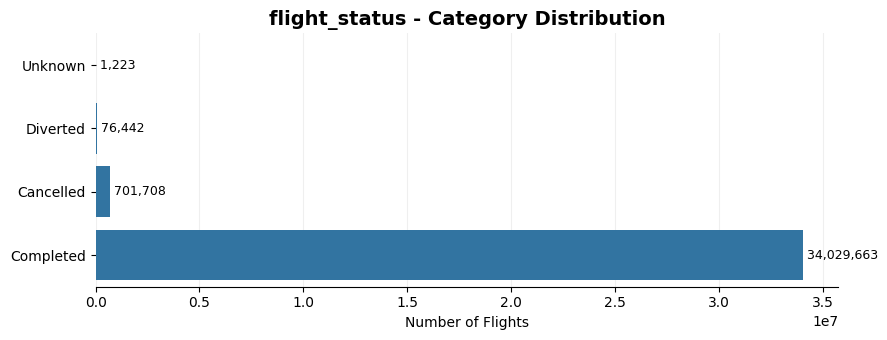

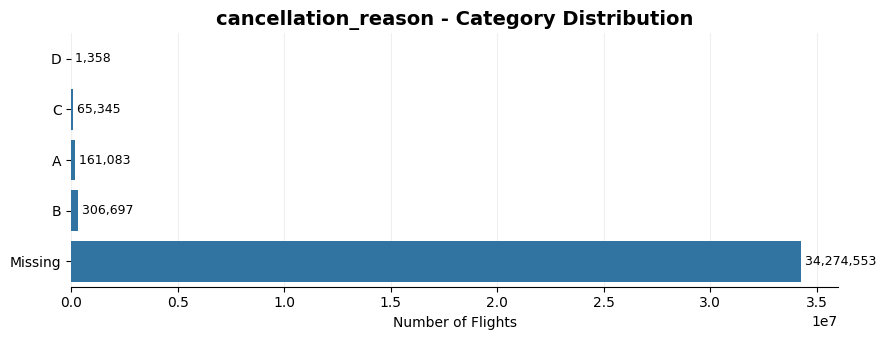

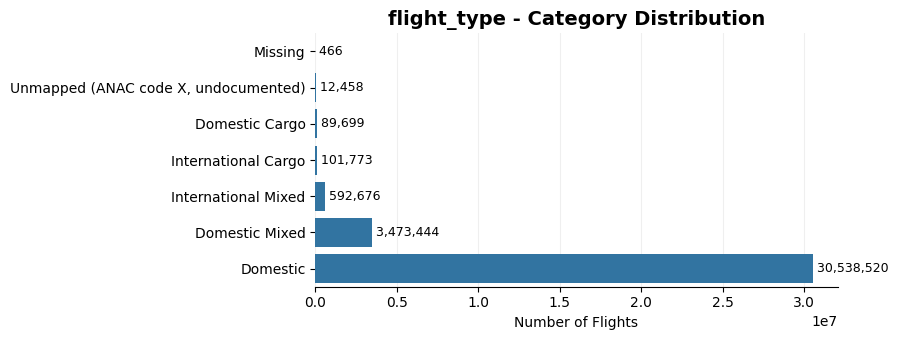

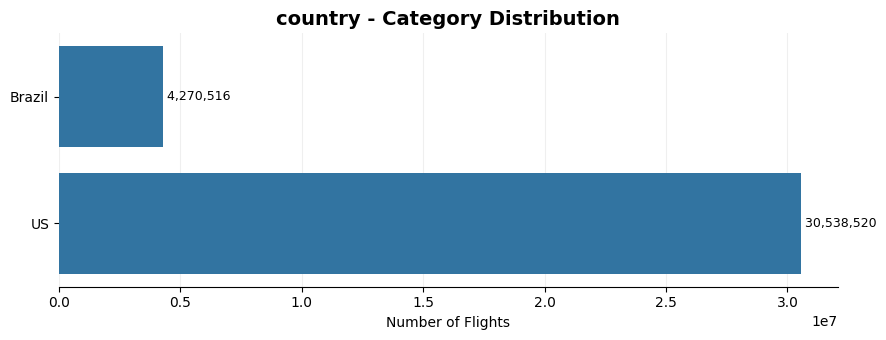

In [22]:
# Sample for plotting — avoids plotting millions of rows
plot_df = df.sample(
    min(100_000, len(df)),
    random_state=42
)

# Identify categorical columns from the plotting dataframe
categorical_cols = plot_df.select_dtypes(
    include=["object", "category"]
).columns

# Keep only low-cardinality categorical columns
low_cardinality_cols = [
    col for col in categorical_cols
    if plot_df[col].nunique(dropna=False) <= 20
]

print("Low-cardinality categorical columns:")
print(list(low_cardinality_cols))


for col in low_cardinality_cols:

    counts = (
        df[col]
        .astype("object")
        .fillna("Missing")
        .value_counts()
        .sort_values(ascending=True)
    )

    fig_height = max(3.5, len(counts) * 0.45)

    plt.figure(figsize=(9, fig_height))

    ax = sns.barplot(
        x=counts.values,
        y=counts.index.astype(str),
        orient="h"
    )

    plt.title(
        f"{col} - Category Distribution",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Number of Flights")
    plt.ylabel("")

    for i, value in enumerate(counts.values):
        ax.text(
            value, i,
            f" {value:,.0f}",
            va="center",
            fontsize=9
        )

    sns.despine(left=True, bottom=False)
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

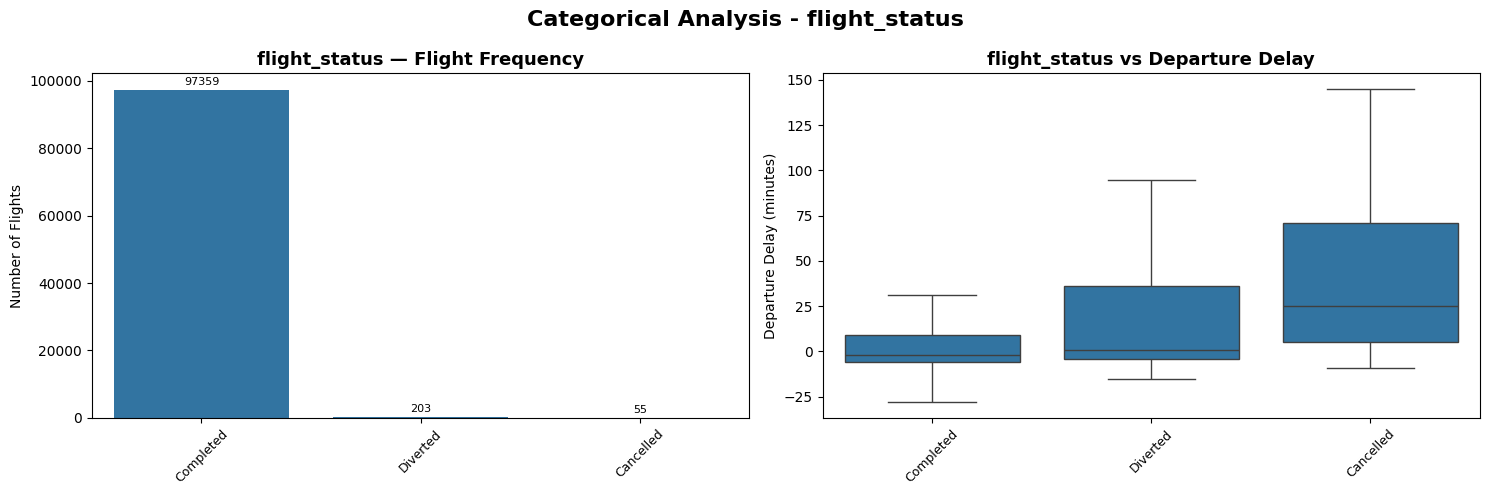

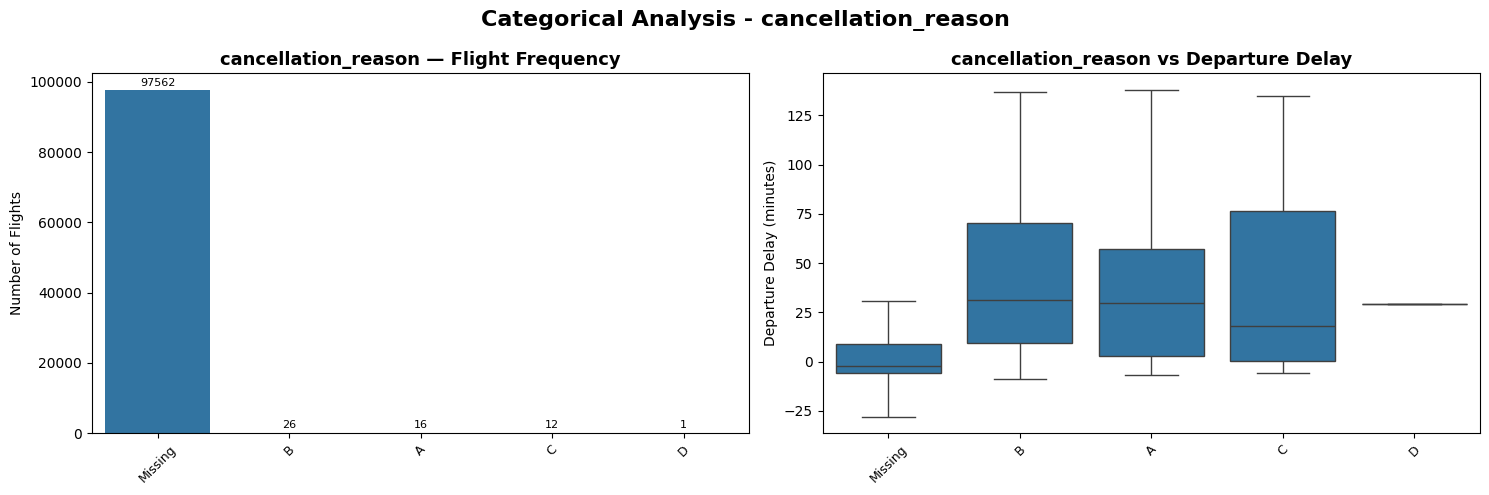

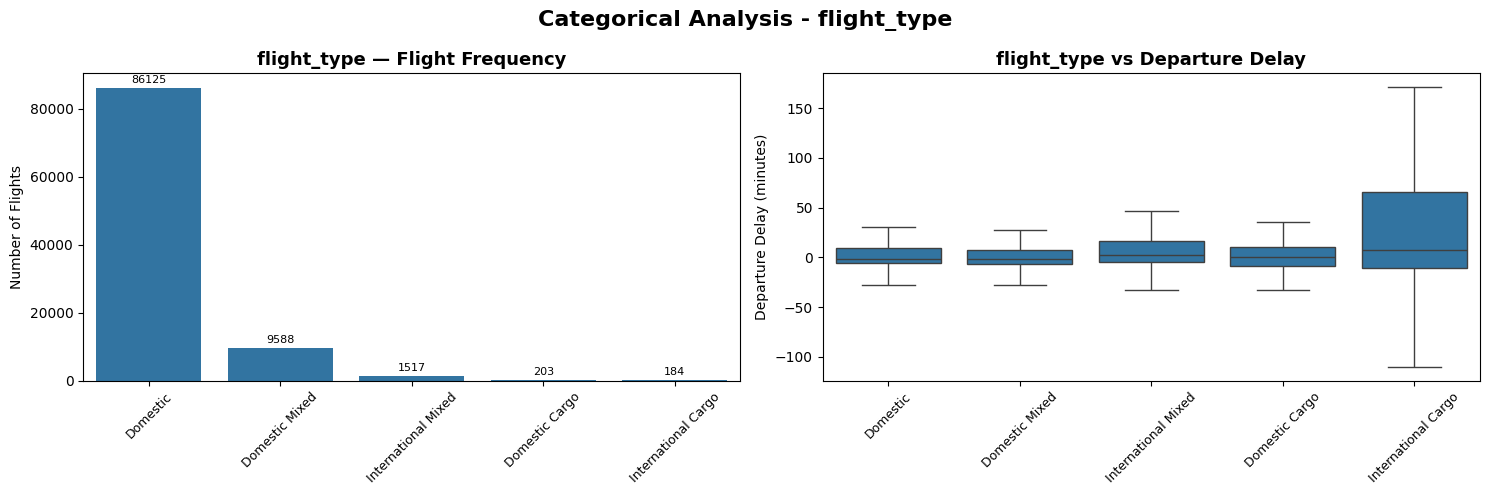

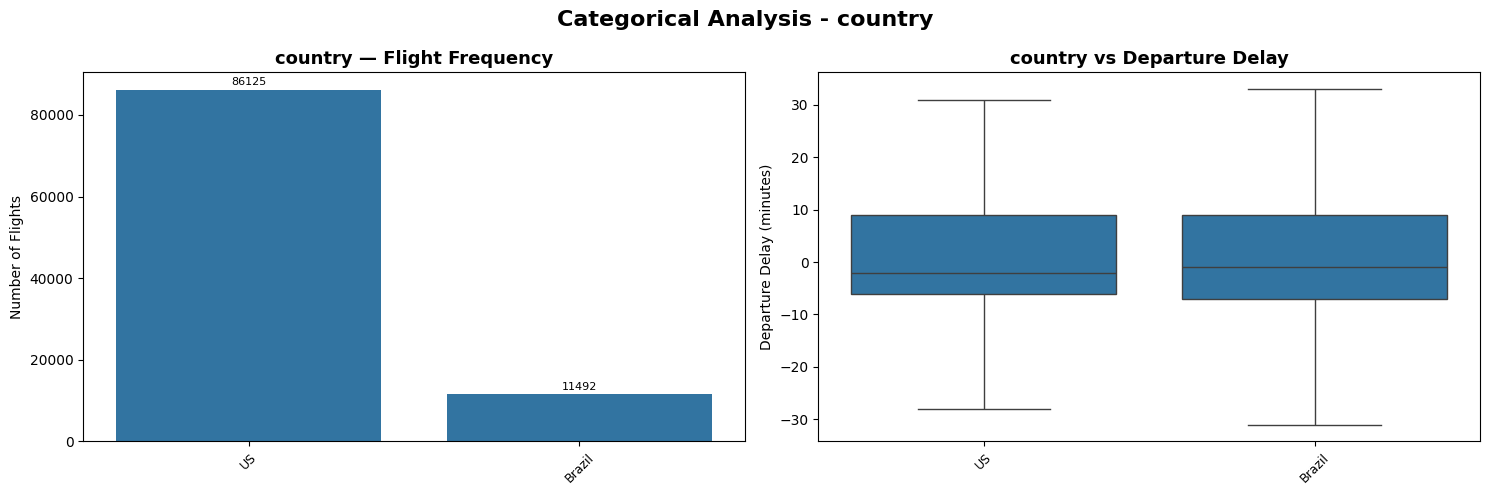

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample for visualization
plot_df = df.sample(
    min(100_000, len(df)),
    random_state=42
).copy()

target = "departure_delay_minutes"

# Low-cardinality categorical columns
low_cardinality_cols = [
    col
    for col in categorical_cols
    if df[col].nunique(dropna=False) <= 20
]

for col in low_cardinality_cols:

    temp = plot_df[[col, target]].copy()

    # Safely handle categorical dtype
    temp[col] = temp[col].astype("object").fillna("Missing")

    # Remove rows where target is missing
    temp = temp.dropna(subset=[target])

    # Order categories by frequency
    order = temp[col].value_counts().index

    fig, axes = plt.subplots(
        1, 2,
        figsize=(15, 5)
    )

    # ================================================
    # 1. CATEGORY FREQUENCY
    # ================================================
    sns.countplot(
        data=temp,
        x=col,
        order=order,
        ax=axes[0]
    )

    axes[0].set_title(
        f"{col} — Flight Frequency",
        fontsize=13,
        fontweight="bold"
    )

    axes[0].set_xlabel("")
    axes[0].set_ylabel("Number of Flights")

    axes[0].tick_params(
        axis="x",
        rotation=45,
        labelsize=9
    )

    # Add count labels
    for container in axes[0].containers:
        axes[0].bar_label(
            container,
            fmt="%.0f",
            fontsize=8,
            padding=2
        )

    # ================================================
    # 2. CATEGORY vs TARGET
    # ================================================
    sns.boxplot(
        data=temp,
        x=col,
        y=target,
        order=order,
        ax=axes[1],
        showfliers=False
    )

    axes[1].set_title(
        f"{col} vs Departure Delay",
        fontsize=13,
        fontweight="bold"
    )

    axes[1].set_xlabel("")
    axes[1].set_ylabel("Departure Delay (minutes)")

    axes[1].tick_params(
        axis="x",
        rotation=45,
        labelsize=9
    )

    plt.suptitle(
        f"Categorical Analysis - {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

### Data Cleaning & Preprocessing

In [24]:
missing_analysis = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_%": df.isna().mean() * 100,
    "Unique_Count": df.nunique(dropna=True),
    "Data_Type": df.dtypes
})

missing_analysis = (
    missing_analysis[missing_analysis["Missing_Count"] > 0]
    .sort_values("Missing_%", ascending=False)
)

missing_analysis

,Missing_Count,Missing_%,Unique_Count,Data_Type
cancellation_reason,34274553,98.46,4,category
snowfall_cm,28061125,80.61,420,float32
weathercode,25948384,74.54,83,float64
windgusts_10m_ms,24776071,71.18,2043,float32
precipitation_mm,4123583,11.85,4057,float32
cloudcover_low_pct,1994140,5.73,504,float32
arrival_delay_minutes,847125,2.43,5454,float32
departure_delay_minutes,821684,2.36,5365,float32
actual_arrival,710474,2.04,2276126,datetime64[ns]
actual_departure,685033,1.97,2152157,datetime64[ns]


In [25]:
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_analysis = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_count = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()
    
    outlier_percent = outlier_count / len(df) * 100
    
    outlier_analysis.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": outlier_count,
        "Outlier_%": outlier_percent
    })

outlier_df = pd.DataFrame(outlier_analysis)

outlier_df.sort_values(
    "Outlier_%",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
9,visibility_m,"16,046.50","16,093.00",46.50,"15,976.75","16,162.75",12904742,37.07
0,departure_delay_minutes,-6.00,9.00,15.00,-28.50,31.50,4341427,12.47
14,station_distance_km,0.00,0.00,0.00,0.00,0.00,3634897,10.44
1,arrival_delay_minutes,-15.00,9.00,24.00,-51.00,45.00,3232641,9.29
10,precipitation_mm,0.00,0.00,0.00,0.00,0.00,2441455,7.01
2,scheduled_flight_duration_minutes,90.00,177.00,87.00,-40.50,307.50,1877744,5.39
7,windspeed_10m_ms,2.00,4.60,2.60,-1.90,8.50,1000960,2.88
11,snowfall_cm,0.00,0.00,0.00,0.00,0.00,491696,1.41
6,temperature_2m_c,10.00,24.40,14.40,-11.60,46.00,242320,0.70
8,windgusts_10m_ms,4.10,10.80,6.70,-5.95,20.85,29473,0.08


### We are keeping all the outlier in our dataset because they are all valid data. The IQR did its work but thelower and the upper bound doesn't make sense with the this kind of data 

### Let's handle the missing values now 

In [26]:
imputation_plan = {
    "median": [
        "temperature_2m_c",
        "windspeed_10m_ms",
        "visibility_m",
        "precipitation_mm",
        "cloudcover_low_pct",
        "station_distance_km",
        "scheduled_flight_duration_minutes"
    ],
    
    "mode": [
        "flight_type",
        "weather_station_id",
        "is_substitute_station"
    ],
    
    "derive": [
        "hour_of_day",
        "day_of_week",
        "month"
    ],
    
    "keep_missing": [
        "snowfall_cm",
        "weathercode",
        "windgusts_10m_ms",
        "actual_departure",
        "actual_arrival"
    ],
    
    "target": [
        "departure_delay_minutes"
    ]
}

for strategy, columns in imputation_plan.items():
    print(f"\n{strategy.upper()}")
    for col in columns:
        print(f"  - {col}")


MEDIAN
  - temperature_2m_c
  - windspeed_10m_ms
  - visibility_m
  - precipitation_mm
  - cloudcover_low_pct
  - station_distance_km
  - scheduled_flight_duration_minutes

MODE
  - flight_type
  - weather_station_id
  - is_substitute_station

DERIVE
  - hour_of_day
  - day_of_week
  - month

KEEP_MISSING
  - snowfall_cm
  - weathercode
  - windgusts_10m_ms
  - actual_departure
  - actual_arrival

TARGET
  - departure_delay_minutes


In [27]:
df.isnull().sum()

airline                                     0
flight_number                               1
origin_airport                              0
destination_airport                         0
scheduled_departure                    136651
actual_departure                       685033
scheduled_arrival                      136653
actual_arrival                         710474
flight_status                               0
cancellation_reason                  34274553
flight_type                               466
country                                     0
cancellation_reason_available               0
departure_delay_minutes                821684
has_departure_delay_target                  0
arrival_delay_minutes                  847125
scheduled_flight_duration_minutes      136653
hour_of_day                            136651
day_of_week                            136651
month                                  136651
is_weekend                                  0
is_redeye                         

In [29]:
median_cols = [
    "temperature_2m_c",
    "windspeed_10m_ms",
    "visibility_m",
    "precipitation_mm",
    "cloudcover_low_pct",
    "station_distance_km",
    "scheduled_flight_duration_minutes"
]

median_values = df[median_cols].median()

median_values

temperature_2m_c                        18.00
windspeed_10m_ms                         3.10
visibility_m                        16,093.00
precipitation_mm                         0.00
cloudcover_low_pct                      25.00
station_distance_km                      0.00
scheduled_flight_duration_minutes      127.00
dtype: float32

In [31]:
median_check = pd.DataFrame({
    "Missing_Before": df[median_cols].isna().sum(),
    "Median": df[median_cols].median()
})

median_check

,Missing_Before,Median
temperature_2m_c,352237,18.00
windspeed_10m_ms,362336,3.10
visibility_m,417654,"16,093.00"
precipitation_mm,4123583,0.00
cloudcover_low_pct,1994140,25.00
station_distance_km,667402,0.00
scheduled_flight_duration_minutes,136653,127.00


In [32]:
categorical_impute_cols = [
    "flight_type",
    "weather_station_id",
    "is_substitute_station"
]

mode_values = df[categorical_impute_cols].mode().iloc[0]

mode_values

flight_type              Domestic
weather_station_id              0
is_substitute_station       False
Name: 0, dtype: object

In [33]:
mode_check = pd.DataFrame({
    "Missing_Before": df[categorical_impute_cols].isna().sum(),
    "Mode": mode_values
})

mode_check

,Missing_Before,Mode
flight_type,466,Domestic
weather_station_id,31783,0
is_substitute_station,324051,False


In [38]:
df.head()

,airline,flight_number,origin_airport,destination_airport,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,flight_status,cancellation_reason,flight_type,country,cancellation_reason_available,departure_delay_minutes,has_departure_delay_target,arrival_delay_minutes,scheduled_flight_duration_minutes,hour_of_day,day_of_week,month,is_weekend,is_redeye,route,weather_hour,temperature_2m_c,windspeed_10m_ms,windgusts_10m_ms,visibility_m,precipitation_mm,snowfall_cm,cloudcover_low_pct,weathercode,weather_station_id,is_substitute_station,station_distance_km
0,9E,4732,ABE,DTW,2022-04-01 05:55:00,2022-04-01 06:09:00,2022-04-01 07:54:00,2022-04-01 07:45:00,Completed,NaN,Domestic,US,False,14.00,True,-9.00,119.00,5,4,4,False,True,ABE-DTW,2022-04-01 05:00:00,12.78,1.04,NaN,"3,701.40",0.48,NaN,30.00,61.00,72517014737,False,0.00
1,OH,5600,ABE,CLT,2022-04-01 06:05:00,2022-04-01 06:00:00,2022-04-01 08:20:00,2022-04-01 07:44:00,Completed,NaN,Domestic,US,False,-5.00,True,-36.00,135.00,6,4,4,False,True,ABE-CLT,2022-04-01 06:00:00,12.50,3.10,NaN,"5,628.00",18.50,NaN,87.50,10.00,72517014737,False,0.00
2,G4,312,ABE,PGD,2022-04-01 07:00:00,2022-04-01 06:57:00,2022-04-01 09:40:00,2022-04-01 09:55:00,Completed,NaN,Domestic,US,False,-3.00,True,15.00,160.00,7,4,4,False,False,ABE-PGD,2022-04-01 07:00:00,11.10,3.10,NaN,"16,093.00",0.00,NaN,87.50,NaN,72517014737,False,0.00
3,G4,403,ABE,PIE,2022-04-01 08:00:00,2022-04-01 12:50:00,2022-04-01 10:36:00,2022-04-01 15:43:00,Completed,NaN,Domestic,US,False,290.00,True,307.00,156.00,8,4,4,False,False,ABE-PIE,2022-04-01 08:00:00,10.60,4.60,NaN,"16,093.00",0.00,NaN,25.00,NaN,72517014737,False,0.00
4,G4,401,ABE,SFB,2022-04-01 12:53:00,2022-04-01 13:26:00,2022-04-01 15:18:00,2022-04-01 15:59:00,Completed,NaN,Domestic,US,False,33.00,True,41.00,145.00,12,4,4,False,False,ABE-SFB,2022-04-01 12:00:00,8.60,3.60,NaN,"16,046.50",0.50,NaN,87.50,NaN,72517014737,False,0.00


In [39]:
# ============================================================
# APPROVED DATA CLEANING
# ============================================================

# 1. Derive scheduled flight duration
df["scheduled_flight_duration_minutes"] = (
    df["scheduled_arrival"] - df["scheduled_departure"]
).dt.total_seconds() / 60


# 2. Derive time-based features
df["hour_of_day"] = (
    df["scheduled_departure"]
    .dt.hour
    .astype("Int8")
)

df["day_of_week"] = (
    df["scheduled_departure"]
    .dt.dayofweek
    .astype("Int8")
)

df["month"] = (
    df["scheduled_departure"]
    .dt.month
    .astype("Int8")
)


# 3. Mode imputation for flight_type
flight_type_mode = df["flight_type"].mode()[0]

df["flight_type"] = df["flight_type"].fillna(
    flight_type_mode
)


# ============================================================
# VALIDATION
# ============================================================

print("flight_type mode used:", flight_type_mode)

print("\nMissing values after processing:")
print(
    df[
        [
            "scheduled_flight_duration_minutes",
            "hour_of_day",
            "day_of_week",
            "month",
            "flight_type"
        ]
    ].isna().sum()
)

print("\nDerived feature statistics:")
display(
    df[
        [
            "scheduled_flight_duration_minutes",
            "hour_of_day",
            "day_of_week",
            "month"
        ]
    ].describe()
)

flight_type mode used: Domestic

Missing values after processing:
scheduled_flight_duration_minutes    136653
hour_of_day                          136651
day_of_week                          136651
month                                136651
flight_type                               0
dtype: int64

Derived feature statistics:


,scheduled_flight_duration_minutes,hour_of_day,day_of_week,month
count,"34,672,383.00","34,672,385.00","34,672,385.00","34,672,385.00"
mean,147.82,12.99,2.98,6.24
std,84.17,5.02,2.00,3.43
min,-272.00,0.00,0.00,1.00
25%,90.00,9.00,1.00,3.00
50%,127.00,13.00,3.00,6.00
75%,177.00,17.00,5.00,9.00
max,"1,510.00",23.00,6.00,12.00


In [40]:
df["is_substitute_station"].value_counts(dropna=False)

is_substitute_station
False    34484985
<NA>       324051
Name: count, dtype: Int64

In [41]:
missing_station = df[df["weather_station_id"].isna()]

print(f"Missing: {len(missing_station):,}")

missing_station[
    [
        "origin_airport",
        "destination_airport",
        "weather_hour",
        "station_distance_km",
        "is_substitute_station"
    ]
].head(20)

Missing: 31,783


,origin_airport,destination_airport,weather_hour,station_distance_km,is_substitute_station
499755,PVU,SNA,2022-04-24 09:00:00,NaN,<NA>
499756,TBN,DEC,2022-04-25 10:00:00,NaN,<NA>
499757,BQN,JFK,2022-04-26 03:00:00,NaN,<NA>
499758,BQN,FLL,2022-04-26 03:00:00,NaN,<NA>
499759,BQN,MCO,2022-04-26 01:00:00,NaN,<NA>
499760,BQN,EWR,2022-04-26 01:00:00,NaN,<NA>
499761,BQN,MCO,2022-04-04 01:00:00,NaN,<NA>
499762,BQN,EWR,2022-04-04 01:00:00,NaN,<NA>
499763,PSE,MCO,2022-04-05 08:00:00,NaN,<NA>
499764,RDD,SFO,2022-04-05 20:00:00,NaN,<NA>


In [42]:
df.loc[
    df["weather_station_id"].isna(),
    "is_substitute_station"
].value_counts(dropna=False)

is_substitute_station
<NA>    31783
Name: count, dtype: Int64

In [43]:
df.loc[
    df["weather_station_id"].isna(),
    "station_distance_km"
].describe()

count   0.00
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: station_distance_km, dtype: float64

In [46]:
df["temperature_2m_c"].describe()


count   34,456,799.00
mean            16.77
std              9.68
min            -47.00
25%             10.00
50%             18.00
75%             24.40
max             51.70
Name: temperature_2m_c, dtype: float64

In [47]:
df.loc[
    df["temperature_2m_c"].isna(),
    ["origin_airport", "weather_hour", "weather_station_id"]
].head(20)

,origin_airport,weather_hour,weather_station_id
2727,ABI,2022-04-23 16:00:00,72266013962
2728,ABI,2022-04-24 06:00:00,72266013962
2729,ABI,2022-04-24 08:00:00,72266013962
2730,ABI,2022-04-24 09:00:00,72266013962
2731,ABI,2022-04-24 10:00:00,72266013962
2734,ABI,2022-04-25 06:00:00,72266013962
2736,ABI,2022-04-25 09:00:00,72266013962
2737,ABI,2022-04-25 10:00:00,72266013962
19841,BQN,2022-04-03 03:00:00,78514011603
19851,BQN,2022-04-07 03:00:00,78514011603


In [48]:
df["temperature_2m_c"].skew()

np.float32(-0.53205377)

In [49]:
df["windspeed_10m_ms"].describe()

count   34,446,700.00
mean             3.48
std              2.13
min              0.00
25%              2.00
50%              3.10
75%              4.60
max             50.40
Name: windspeed_10m_ms, dtype: float64

In [50]:
df["windspeed_10m_ms"].skew()

np.float32(0.85289496)

In [51]:
df.loc[
    df["windspeed_10m_ms"].isna(),
    ["origin_airport", "weather_hour", "weather_station_id"]
].head(20)

,origin_airport,weather_hour,weather_station_id
175,ABE,2022-04-20 17:00:00,72517014737
1922,ACV,2022-04-15 16:00:00,72594524283
2424,ASE,2022-04-05 07:00:00,72467693073
2768,AEX,2022-04-03 18:00:00,74754093915
3324,AVL,2022-04-17 13:00:00,72315003812
3543,AVL,2022-04-17 13:00:00,72315003812
3639,AVL,2022-04-17 13:00:00,72315003812
3931,ACY,2022-04-20 16:00:00,72407093730
8808,AGS,2022-04-10 16:00:00,72218003820
9044,AGS,2022-04-10 16:00:00,72218003820


In [52]:
df["visibility_m"].describe()

count   34,391,382.00
mean        17,126.63
std         11,000.33
min              0.00
25%         16,046.50
50%         16,093.00
75%         16,093.00
max        160,000.00
Name: visibility_m, dtype: float64

In [53]:
df["visibility_m"].skew()

np.float32(3.6022856)

In [54]:
df.loc[
    df["visibility_m"].isna(),
    ["origin_airport", "weather_hour", "weather_station_id"]
].head(20)

,origin_airport,weather_hour,weather_station_id
2783,AEX,2022-04-06 14:00:00,74754093915
8709,AGS,2022-04-01 05:00:00,72218003820
8710,AGS,2022-04-01 07:00:00,72218003820
8716,AGS,2022-04-02 05:00:00,72218003820
8717,AGS,2022-04-02 07:00:00,72218003820
8722,AGS,2022-04-03 05:00:00,72218003820
8723,AGS,2022-04-03 07:00:00,72218003820
8729,AGS,2022-04-04 05:00:00,72218003820
8730,AGS,2022-04-04 07:00:00,72218003820
8733,AGS,2022-04-04 13:00:00,72218003820


In [55]:
precip_missing = df["precipitation_mm"].isna()

print("Missing precipitation:", precip_missing.sum())

print("\nWeather station source:")
print(
    df.loc[precip_missing, "weather_station_id"]
    .value_counts(dropna=False)
    .head(20)
)

Missing precipitation: 4123583

Weather station source:
weather_station_id
0              3228202
72314013881      73787
74791013717      40647
72537094847      33616
NaN              31783
91182022521      30582
72530094846      30110
72221013858      28840
72259003927      22212
72278023183      22191
72278623104      20799
72793024233      20372
72645704825      20166
74783012849      17380
72205012815      16007
72494023234      15771
72572024127      13274
72211012842      12409
72658014922      12306
72534014819      11996
Name: count, dtype: int64


In [56]:
df.loc[
    precip_missing,
    ["weather_station_id", "weather_hour", "origin_airport"]
].head(20)

,weather_station_id,weather_hour,origin_airport
355,70350025501,2022-04-01 07:00:00,ADQ
1996,72645704825,2022-04-01 05:00:00,ATW
1997,72645704825,2022-04-01 06:00:00,ATW
1998,72645704825,2022-04-01 07:00:00,ATW
1999,72645704825,2022-04-01 08:00:00,ATW
2000,72645704825,2022-04-01 12:00:00,ATW
2001,72645704825,2022-04-01 13:00:00,ATW
2002,72645704825,2022-04-01 14:00:00,ATW
2003,72645704825,2022-04-01 15:00:00,ATW
2004,72645704825,2022-04-01 16:00:00,ATW


In [57]:
print(
    df["precipitation_mm"]
    .isna()
    .groupby(df["weather_station_id"])
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

/tmp/ipykernel_58/1189858142.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(df["weather_station_id"])


weather_station_id
72061600207   1.00
1             1.00
72520754735   0.96
72306513783   0.94
72676494163   0.94
72213653883   0.93
72503814714   0.90
72518699999   0.90
78520300398   0.90
72512854739   0.89
72213263801   0.89
72012063837   0.89
72646594890   0.89
72086800294   0.87
72428513812   0.87
72278623104   0.87
72755014958   0.87
78514011603   0.87
72628494836   0.84
72586594161   0.83
Name: precipitation_mm, dtype: float64


In [58]:
df["cloudcover_low_pct"].describe()

count   32,814,896.00
mean            39.32
std             33.58
min              0.00
25%             16.00
50%             25.00
75%             56.00
max            100.00
Name: cloudcover_low_pct, dtype: float64

In [59]:
df["cloudcover_low_pct"].skew()

np.float32(0.58476007)

In [60]:
df.loc[
    df["cloudcover_low_pct"].isna(),
    ["origin_airport", "weather_hour", "weather_station_id"]
].head(20)

,origin_airport,weather_hour,weather_station_id
2107,ATW,2022-04-13 12:00:00,72645704825
2108,ATW,2022-04-13 14:00:00,72645704825
2109,ATW,2022-04-13 15:00:00,72645704825
2290,ATW,2022-04-13 12:00:00,72645704825
2291,ATW,2022-04-13 15:00:00,72645704825
2410,ASE,2022-04-03 15:00:00,72467693073
2411,ASE,2022-04-03 16:00:00,72467693073
2412,ASE,2022-04-03 17:00:00,72467693073
2475,ASE,2022-04-12 12:00:00,72467693073
2476,ASE,2022-04-12 13:00:00,72467693073


In [61]:
df.loc[
    df["station_distance_km"].isna(),
    [
        "origin_airport",
        "weather_station_id",
        "is_substitute_station"
    ]
].head(20)

,origin_airport,weather_station_id,is_substitute_station
499755,PVU,NaN,<NA>
499756,TBN,NaN,<NA>
499757,BQN,NaN,<NA>
499758,BQN,NaN,<NA>
499759,BQN,NaN,<NA>
499760,BQN,NaN,<NA>
499761,BQN,NaN,<NA>
499762,BQN,NaN,<NA>
499763,PSE,NaN,<NA>
499764,RDD,NaN,<NA>


In [63]:
# Median imputation
df["temperature_2m_c"] = df["temperature_2m_c"].fillna(
    df["temperature_2m_c"].median()
)

In [64]:
# Median imputation
df["windspeed_10m_ms"] = df["windspeed_10m_ms"].fillna(
    df["windspeed_10m_ms"].median()
)

In [65]:
# Median imputation
df["cloudcover_low_pct"] = df["cloudcover_low_pct"].fillna(
    df["cloudcover_low_pct"].median()
)

In [66]:
df.isnull().sum()

airline                                     0
flight_number                               1
origin_airport                              0
destination_airport                         0
scheduled_departure                    136651
actual_departure                       685033
scheduled_arrival                      136653
actual_arrival                         710474
flight_status                               0
cancellation_reason                  34274553
flight_type                                 0
country                                     0
cancellation_reason_available               0
departure_delay_minutes                821684
has_departure_delay_target                  0
arrival_delay_minutes                  847125
scheduled_flight_duration_minutes      136653
hour_of_day                            136651
day_of_week                            136651
month                                  136651
is_weekend                                  0
is_redeye                         

In [67]:
# Fix negative scheduled flight durations caused by crossing midnight
negative_duration = df["scheduled_flight_duration_minutes"] < 0

df.loc[negative_duration, "scheduled_flight_duration_minutes"] += 1440

In [68]:
print("Negative durations:", (df["scheduled_flight_duration_minutes"] < 0).sum())
print("Missing durations:", df["scheduled_flight_duration_minutes"].isna().sum())

display(
    df["scheduled_flight_duration_minutes"].describe()
)

Negative durations: 0
Missing durations: 136653


count   34,672,383.00
mean           147.82
std             84.18
min              0.00
25%             90.00
50%            127.00
75%            177.00
max          1,510.00
Name: scheduled_flight_duration_minutes, dtype: float64